# Connect Four with RL
In this Notebook we will see how to train an AI to play the game of Connect Four. We will train the AI with the so called Reinforcement Learning (RL). For more details on RL, have a look [at this description](https://www.ibm.com/think/topics/reinforcement-learning).


---


In this game, two players alternate turns dropping a colored disc in a board of $n\times m$, where $n$ is the number of rows and $m$ is the number of columns. There are overall two colors, one for each player. The first player to win is the one who successfully places $4$ discs of the same color in either a vertical, a horizontal or a diagonal sequence.

For more details on the game, you can have a quick look at [this page](https://en.wikipedia.org/wiki/Connect_Four).

# 1) Install and import
First, we will import all the packages necessary to train our AI and to plot the outcomes of each game. We will need *tensorflow*, which is pivotal for AI training, and *numpy* to handle arrays and all other mathematical aspects.

In [ ]:
!pip install tensorflowjs -q

import numpy as np
import tensorflow as tf
from tensorflow import keras
import random
import math
import os
from collections import deque
import matplotlib.pyplot as plt

print('TensorFlow: ', tf.__version__)
print('GPU available: ', bool(tf.config.list_physical_devices('GPU')))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
TensorFlow:  2.19.0
GPU available:  False


# 2) The ConnectFour class
Next, we define a class that contains all the necessary moves/checks to play the game. The **board** $b$ object is a numpy array describing the current configuration of the game. Here $b[i, j] \in \{0, 1, 2\}$, where $0$ denotes that the cell $b[i, j]$ is free, $b[i,j]=1$ if the cell is occupied by a disc of player $1$ and $b[i,j]=2$ if the cell is occupied by a disc of player $2$.

Since we use RL, we have to define a policy for the rewards to give to our AI. In this case, we make the following choice:


*   $+1$ point if, with the next move, the AI wins the game;
*   $-1$ point if, with the next move, the opponent wins the game;
* $+0.2$ if, with the next move, the game ends in a tie (no winner).

We also need to reward the AI everytime it chooses to make a move that is in its favor, like: forming a sequence of $3$ discs, forming a sequence of $2$ discs, or preventing the opponent from forming a sequence of $2$ or $3$ discs. For all these intermediate configurations (i.e. the game has not come to an end yet), we choose the following reward system:


*  $+0.05$ points for every $2$-in-a-row sequence that the AI has in the board;
*  $+0.15$ points for every $3$-in-a-row sequence the AI has in the board;
*  $-0.08$ points for every $2$-in-a-row sequence the opponent has in the board;
*  $-0.2$ points for every $3$-in-a-row sequence the opponent has in the board.







In [ ]:
class ConnectFour:
  rows = 6
  cols = 7

  def __init__(self):
    self.board = np.zeros((self.rows, self.cols), dtype=np.int8)
    self.current_player = 1
    self.done = False
    self.winner = None

  def copy(self):
    env = ConnectFour()
    env.board = self.board.copy()
    env.current_player = self.current_player
    env.done = self.done
    env.winner = self.winner
    return env

  def valid_moves(self):
    """ A move is valid if the column is not full """
    return [col for col in range(self.cols) if self.board[0][col]==0]

  def drop_piece(self, col):
    assert col in self.valid_moves(), f'Invalid move: column {col}'
    # Drop the disk in the first (aka lowest) empty row
    for row in range(self.rows-1, -1, -1):
      if self.board[row][col] == 0:
        self.board[row][col] = self.current_player
        break
    # Check for states that terminate the game
    if self.__check_win(self.current_player):
      self.done = True
      self.winner = self.current_player
    elif len(self.valid_moves()) == 0:
      self.done = True
      self.winner = 0 # it's a tie
    else:
      self.current_player *= -1

  def __check_win(self, player):
    b = self.board
    # Check for HORIZONTAL alignements
    for row in range(self.rows):
      for col in range(self.cols - 3):
        if all(b[row][col+i] == player for i in range(4)):
          return True
    # Check for VERTICAL alignements
    for row in range(self.rows - 3):
      for col in range(self.cols):
        if all(b[row+i][col] == player for i in range(4)):
          return True
    # Check for positive DIAGONAL alignements
    for row in range(3, self.rows):
      for col in range(self.cols - 3):
        if all(b[row-i][col+i] == player for i in range(4)):
          return True
    # Check for negative DIAGONAL alignements
    for row in range(self.rows - 3):
      for col in range(self.cols - 3):
        if all(b[row+i][col+i] == player for i in range(4)):
          return True
    return False

  def count_sequences(self, player, length):
    """ Check how many sequences (hor/vert/diag) of length 'length' the player has on the board """
    count = 0
    b = self.board
    # HORIZONTAL
    for r in range(self.rows):
      for c in range(self.cols - length -1):
        window = [b[r][c+i] for i in range(length)]
        if window.count(player) == length and -player not in window:
          count+=1
    # VERTICAL
    for r in range(self.rows - length + 1):
      for c in range(self.cols):
        window = [b[r+i][c] for i in range(length)]
        if window.count(player) == length and -player not in window:
          count +=1
    # NEGATIVE DIAGONAL
    for r in range(self.rows - length + 1):
      for c in range(self.cols - length + 1):
        window = [b[r+i][c+i] for i in range(length)]
        if window.count(player) == length and -player not in window:
          count +=1
    # POSITIVE DIAGONAL
    for r in range(length - 1, self.rows):
      for c in range(self.cols - length + 1):
        window = [b[r-i][c+i] for i in range(length)]
        if window.count(player) == length and -player not in window:
          count +=1
    return count

  def shaped_reward(self, player, done, winner):
    """ Returns a reward depending on the final state (win/loss/tie) and for intermediate configurations as well """
    if done:
      if winner == player: reward = 1.0
      elif winner == -player: reward = -1.0
      else: reward = 0.2
    else:
      reward = 0.0
      reward += 0.05*self.count_sequences(player, 2) # reward for AI building 2-in-a-row seq.
      reward += 0.15*self.count_sequences(player, 3) # reward for AI building 3-in-a-row seq.
      reward -= 0.08*self.count_sequences(-player, 2) # reward for opponent building 2-in-a-row seq.
      reward -= 0.2*self.count_sequences(-player, 3) # reward for opponent building 3-in-a-row seq.
    return float(np.clip(reward, -1.0, 1.0))

  def get_state(self):
    state = np.zeros((self.rows, self.cols, 3), dtype=np.float32)
    state[:, :, 0] = (self.board == self.current_player).astype(np.float32)
    state[:, :, 1] = (self.board == -self.current_player).astype(np.float32)
    for col in self.valid_moves():
      state[:, col, 2] = 1.0
    return state


# 3) The Neural Network: Policy and Value heads
Our Q-network takes in input the board state as a tensor of shape $(6, 7, 3)$, where $6$ is the number of rows, $7$ is the number of columns and:


*   $[:, :, 0]$ is the list of discs belonging to the AI;
*   $[:, :, 1]$ is the list of discs belonging to the opponent;
* $[:, :, 2]$ is the list of valid moves.

The input is passed through 3 convolutional layers, and then through 2 dense layers. The output is **7** Q-values: each of them represents the cumulative reward the AI gets if it chooses that particular move.



In [ ]:
def build_qnetwork(filters=64):
    """
    Input:  (batch, 6, 7, 3)
    Output: (batch, 7)  — one Q-value per column
    """
    inputs = keras.Input(shape=(6, 7, 3))
    x = keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(inputs)
    x = keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    q_values = keras.layers.Dense(7, name='q_values')(x)
    return keras.Model(inputs=inputs, outputs=q_values)

# Two networks: online (trained every step) + target (updated periodically)
online_model = build_qnetwork()
target_model = build_qnetwork()
target_model.set_weights(online_model.get_weights())  # start identical

online_model.summary()
print("\nQ-network built ✓")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 6, 7, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 6, 7, 64)       │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       688,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,831 (3.04 MB)

 Trainable params: 797,831 (3.04 MB)

 Non-trainable params: 0 (0.00 B)


Q-network built ✓


# 4) Replay-Buffer and Agent
Here we define the class that will be later on used to train our AI. Of particular importance here are the two following:


*   *play_one_episode* function: it describes how one game is carried out. Notice that the AI plays against itself $50$% if the time! The remaining time, if plays against a random opponent (the opponent selects the move randomly from the list of valid moves).
*   *select_action* function: it determines how the AI chooses the next action.

### Action Selection: Epsilon-Greedy Policy

The agent faces a fundamental dilemma at every move: should it **explore**
(try something new) or **exploit** (play what it currently thinks is best)?

`select_action` resolves this with an epsilon-greedy strategy:
- With probability **ε (epsilon)**, the agent picks a random legal move → *exploration*
- With probability **1 - ε**, the agent asks the Q-network which move looks best → *exploitation*

Early in training ε is close to 1, so the agent explores almost randomly and
builds up diverse experiences in the replay buffer. As training progresses,
ε decays toward 0.05, and the agent increasingly trusts what it has learned.

One important detail: the raw Q-values cover all 7 columns, but some columns
may be full. Before picking the best move, illegal columns are masked to `-inf`
so they can never be selected by `argmax`.



In [ ]:

class DQNReplayBuffer:
    """Stores (state, action, reward, next_state, done) transitions."""
    def __init__(self, max_size=50_000):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s, dtype=np.float32),
                np.array(a, dtype=np.int32),
                np.array(r, dtype=np.float32),
                np.array(s2, dtype=np.float32),
                np.array(d, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


def select_action(state, env, epsilon):
    """Epsilon-greedy: explore randomly or exploit Q-values."""
    legal = env.valid_moves()
    if random.random() < epsilon:
        return random.choice(legal)                            # explore
    q = online_model(state[np.newaxis], training=False).numpy()[0]
    q_masked = np.full(7, -np.inf)
    q_masked[legal] = q[legal]                                # mask illegal
    return int(np.argmax(q_masked))                           # exploit


def play_one_episode(epsilon):
    """
    Play one full game: agent (player 1) vs opponent (player -1).
    Returns list of transitions for the replay buffer.
    """
    env = ConnectFour()
    transitions = []

    while not env.done:
        state = env.get_state()

        if env.current_player == 1:
            action = select_action(state, env, epsilon)
            env.drop_piece(action)
            reward = env.shaped_reward(1, env.done, env.winner)
            next_state = env.get_state()
            transitions.append((state, action, reward, next_state, env.done))
        else:
            if random.random() < 0.5:
                # opponent plays greedily 50% of the time using current model
                opp_state = env.get_state()
                q = online_model(opp_state[np.newaxis], training=False).numpy()[0]
                legal = env.valid_moves()
                q_masked = np.full(7, -np.inf)
                q_masked[legal] = q[legal]
                action = int(np.argmax(q_masked))
            else:
                action = random.choice(env.valid_moves())
            env.drop_piece(action)

        # penalization if the game is over and opponent won
        if env.done and env.winner == -1 and transitions:
            s, a, _, ns, _ = transitions[-1]
            transitions[-1] = (s, a, -1.0, ns, True)

    return transitions


print("DQN agent functions ready ✓")

DQN agent functions ready ✓


# 5) Training
Here is where things get real! We can finally start training the AI! The AI will play $15000$ games: the Q-network is fed with batches of size $128$. Here's a short explanation of the hyperparameters used:

### Hyperparameters

| Parameter | Value | Explanation |
|---|---|---|
| `N_EPISODES` | 15,000 | Total self-play games. More episodes = more experience, but longer training. |
| `BATCH_SIZE` | 128 | Number of transitions sampled from the replay buffer per training step. Larger batches give more stable gradient estimates. |
| `GAMMA` | 0.95 | Discount factor — how much the agent values *future* rewards vs *immediate* ones. 0.95 means a reward 10 steps away is worth 0.95¹⁰ ≈ 60% of an immediate reward. |
| `EPSILON_START` | 1.0 | Agent starts fully random — it knows nothing, so pure exploration makes sense. |
| `EPSILON_END` | 0.05 | Epsilon never drops to zero: the agent keeps a 5% chance of random moves even late in training, preventing it from getting stuck in a fixed strategy. |
| `EPSILON_DECAY` | 0.9997 | Epsilon is multiplied by this value each episode. With 15,000 episodes it reaches 0.05 around episode 11,000 — giving the agent plenty of time to explore before committing to greedy play. |
| `TARGET_UPDATE` | 300 | Every 300 episodes, the target network's weights are synced from the online network. Less frequent updates = more stable Q-value targets. |
| `TRAIN_START` | 500 | Training only begins once 500 transitions are in the replay buffer. This ensures the first batches are sufficiently varied and not just copies of the same early game. |
| `EVAL_EVERY` | 500 | Win rate is evaluated every 500 episodes by playing 50 test games. Less frequent evaluation speeds up training. |

One hyperparameter that required careful tuning was `EPSILON_DECAY`.
An earlier run used 0.997, which caused epsilon to hit its floor around
episode 1,000 — far too early. The agent had barely explored before being
forced to act greedily, and its win rate collapsed. Slowing the decay
to 0.9997 gave the agent the exploration time it needed to build a solid policy.

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────
N_EPISODES       = 15000   # total games to play
BATCH_SIZE       = 128
GAMMA            = 0.95   # discount factor
EPSILON_START    = 1.0    # start fully random
EPSILON_END      = 0.05   # end mostly greedy
EPSILON_DECAY    = 0.9997  # multiply epsilon each episode
TARGET_UPDATE    = 300     # copy weights to target network every N episodes
TRAIN_START      = 500    # start training after this many samples
EVAL_EVERY       = 500    # evaluate win rate every N episodes
# ─────────────────────────────────────────────────────────────

optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
replay_buffer = DQNReplayBuffer()
epsilon = EPSILON_START

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, 6, 7, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,),          dtype=tf.int32),
    tf.TensorSpec(shape=(None,),          dtype=tf.float32),
    tf.TensorSpec(shape=(None, 6, 7, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,),          dtype=tf.float32),
])
def train_step(states, actions, rewards, next_states, dones):
    # Target Q-values using Bellman equation
    next_q_online = online_model(next_states, training=False)
    next_actions = tf.argmax(next_q_online, axis=1)
    next_actions = tf.cast(next_actions, tf.int32)
    indices = tf.stack([tf.range(tf.shape(next_actions)[0]), next_actions], axis=1)
    max_next_q = tf.gather_nd(target_model(next_states, training=False), indices)
    targets = rewards + GAMMA * max_next_q * (1.0 - dones)

    with tf.GradientTape() as tape:
        q_values = online_model(states, training=True)
        # Pick Q-value for the action that was actually taken
        indices = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
        taken_q = tf.gather_nd(q_values, indices)
        loss = tf.reduce_mean((targets - taken_q) ** 2)

    grads = tape.gradient(loss, online_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, online_model.trainable_variables))
    return loss


def evaluate(n_games=50):
    """Win rate of agent (player 1) vs random opponent."""
    wins = draws = losses = 0
    for _ in range(n_games):
        env = ConnectFour()
        while not env.done:
            if env.current_player == 1:
                state = env.get_state()
                q = online_model(state[np.newaxis], training=False).numpy()[0]
                legal = env.valid_moves()
                q_masked = np.full(7, -np.inf)
                q_masked[legal] = q[legal]
                move = int(np.argmax(q_masked))
            else:
                move = random.choice(env.valid_moves())
            env.drop_piece(move)
        if   env.winner ==  1: wins   += 1
        elif env.winner == -1: losses += 1
        else:                  draws  += 1
    return wins, draws, losses


# ── Training ──────────────────────────────────────────────────
log = {'episode': [], 'loss': [], 'win_rate': [], 'epsilon': []}
losses_this_block = []

print('Starting DQN training...\n')
print(f'{"Episode":>8}  {"Loss":>7}  {"W-D-L":>12}  {"Win%":>5}  {"ε":>5}')
print('-' * 52)

for episode in range(1, N_EPISODES + 1):

    # Collect one episode
    transitions = play_one_episode(epsilon)
    for t in transitions:
        replay_buffer.add(*t)

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Train if we have enough data
    if len(replay_buffer) >= TRAIN_START:
        s, a, r, s2, d = replay_buffer.sample(BATCH_SIZE)
        loss = train_step(
            tf.constant(s), tf.constant(a), tf.constant(r),
            tf.constant(s2), tf.constant(d)
        )
        losses_this_block.append(float(loss))

    # Sync target network
    if episode % TARGET_UPDATE == 0:
        target_model.set_weights(online_model.get_weights())

    # Evaluate + log
    if episode % EVAL_EVERY == 0:
        avg_loss = np.mean(losses_this_block) if losses_this_block else 0
        losses_this_block = []
        w, d, l = evaluate(n_games=50)
        win_rate = w / 50
        log['episode'].append(episode)
        log['loss'].append(avg_loss)
        log['win_rate'].append(win_rate)
        log['epsilon'].append(epsilon)
        print(f'{episode:>8}  {avg_loss:>7.3f}  '
              f'{w:>3}W {d:>2}D {l:>3}L  {win_rate:>5.0%}  {epsilon:>5.3f}')

print('\nTraining complete!')

Starting DQN training...

 Episode     Loss         W-D-L   Win%      ε
----------------------------------------------------
     500    0.105   41W  0D   9L    82%  0.861
    1000    0.090   43W  0D   7L    86%  0.741
    1500    0.086   45W  0D   5L    90%  0.638
    2000    0.080   45W  0D   5L    90%  0.549
    2500    0.079   47W  0D   3L    94%  0.472
    3000    0.075   47W  0D   3L    94%  0.407
    3500    0.070   42W  0D   8L    84%  0.350
    4000    0.067   44W  0D   6L    88%  0.301
    4500    0.064   41W  0D   9L    82%  0.259
    5000    0.064   46W  0D   4L    92%  0.223
    5500    0.064   42W  0D   8L    84%  0.192
    6000    0.060   46W  0D   4L    92%  0.165
    6500    0.059   40W  0D  10L    80%  0.142
    7000    0.057   34W  0D  16L    68%  0.122
    7500    0.055   41W  0D   9L    82%  0.105
    8000    0.055   40W  0D  10L    80%  0.091
    8500    0.052   44W  0D   6L    88%  0.078
    9000    0.051   41W  0D   9L    82%  0.067
    9500    0.049   45W  0D  

In [ ]:
# ── Fine-tuning: 500 episodes vs pure random, low epsilon ──
print('Fine-tuning...\n')
print(f'{"Episode":>8}  {"Loss":>7}  {"W-D-L":>12}  {"Win%":>5}')
print('-' * 44)

EPSILON_FINE = 0.05
ft_losses = []

for episode in range(1, 501):
    env = ConnectFour()
    transitions = []

    while not env.done:
        state = env.get_state()
        if env.current_player == 1:
            action = select_action(state, env, EPSILON_FINE)
            env.drop_piece(action)
            reward = env.shaped_reward(1, env.done, env.winner)  # ← this
            next_state = env.get_state()
            transitions.append((state, action, reward, next_state, env.done))
        else:
            env.drop_piece(random.choice(env.valid_moves()))
            if env.done and env.winner == -1 and transitions:
                s, a, _, ns, _ = transitions[-1]
                transitions[-1] = (s, a, -1.0, ns, True)

    for t in transitions:
        replay_buffer.add(*t)

    if len(replay_buffer) >= BATCH_SIZE:
        s, a, r, s2, d = replay_buffer.sample(BATCH_SIZE)
        loss = train_step(tf.constant(s), tf.constant(a), tf.constant(r),
                          tf.constant(s2), tf.constant(d))
        ft_losses.append(float(loss))

    if episode % 100 == 0:
        avg_loss = np.mean(ft_losses[-100:])
        w, d, l = evaluate(n_games=50)
        print(f'{episode:>8}  {avg_loss:>7.3f}  '
              f'{w:>3}W {d:>2}D {l:>3}L  {w/50:>5.0%}')

print('\nFine-tuning complete!')

Fine-tuning...

 Episode     Loss         W-D-L   Win%
--------------------------------------------
     100    0.041   44W  0D   6L    88%
     200    0.039   39W  0D  11L    78%
     300    0.039   40W  0D  10L    80%
     400    0.040   42W  0D   8L    84%
     500    0.040   35W  0D  15L    70%

Fine-tuning complete!


# 6) Plotting some training curves

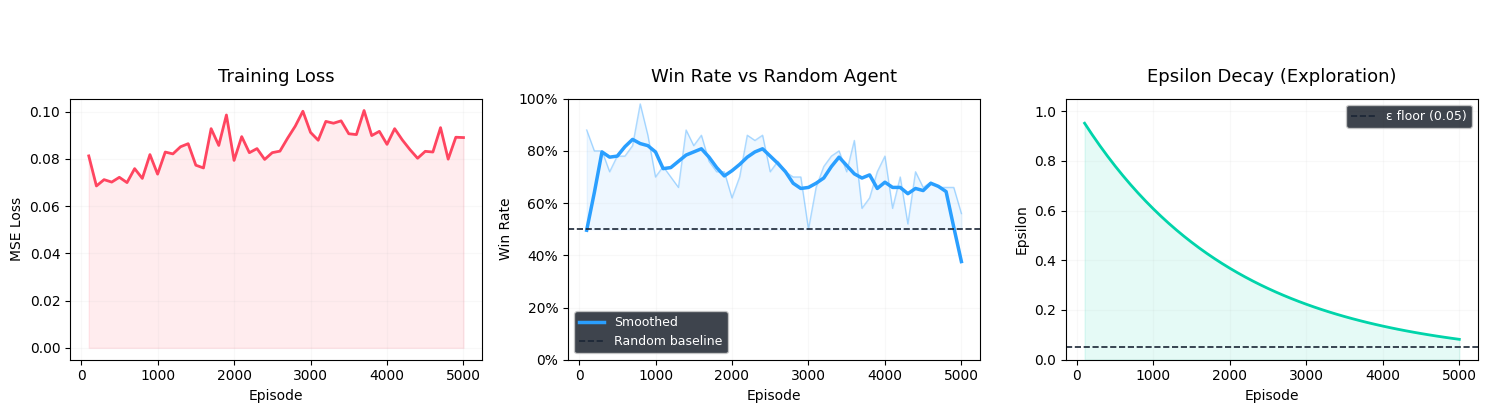

Saved training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#fig.patch.set_facecolor('#1a1a1a')

"""for ax in axes:
    ax.set_facecolor('#080c10')
    ax.tick_params(colors='#6a8aaa')
    ax.xaxis.label.set_color('#6a8aaa')
    ax.yaxis.label.set_color('#6a8aaa')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2535')"""

episodes = log['episode']

# ── Plot 1: Loss ──────────────────────────────────────────────
axes[0].plot(episodes, log['loss'], color='#ff4560', linewidth=2)
axes[0].fill_between(episodes, log['loss'], alpha=0.1, color='#ff4560')
axes[0].set_title('Training Loss', fontsize=13, pad=12)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.08)

# ── Plot 2: Win Rate ──────────────────────────────────────────
win_rates = log['win_rate']

# Smoothed line (rolling average over 5 points)
smooth = np.convolve(win_rates, np.ones(5)/5, mode='same')

axes[1].plot(episodes, win_rates, color='#2a9fff', linewidth=1, alpha=0.35)
axes[1].plot(episodes, smooth,    color='#2a9fff', linewidth=2.5, label='Smoothed')
axes[1].axhline(0.5, color='#1a2535', linestyle='--', linewidth=1.2, label='Random baseline')
axes[1].fill_between(episodes, win_rates, 0.5,
                     where=[w >= 0.5 for w in win_rates],
                     alpha=0.08, color='#2a9fff')
axes[1].set_title('Win Rate vs Random Agent', fontsize=13, pad=12)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend(facecolor='#0e1520', labelcolor='white', fontsize=9)
axes[1].grid(True, alpha=0.08)

# ── Plot 3: Epsilon decay ─────────────────────────────────────
axes[2].plot(episodes, log['epsilon'], color='#00d4aa', linewidth=2)
axes[2].fill_between(episodes, log['epsilon'], alpha=0.1, color='#00d4aa')
axes[2].axhline(0.05, color='#1a2535', linestyle='--', linewidth=1.2, label='ε floor (0.05)')
axes[2].set_title('Epsilon Decay (Exploration)', fontsize=13, pad=12)
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Epsilon')
axes[2].set_ylim(0, 1.05)
axes[2].legend(facecolor='#0e1520', labelcolor='white', fontsize=9)
axes[2].grid(True, alpha=0.08)

plt.suptitle('Connect Four DQN — Training Summary',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0e1520')
plt.show()
print('Saved training_curves.png')

# 7) Save the model
We export our model so that we can use it to play an interactive game.

In [ ]:
online_model.export('connect_four_savedmodel')
print('SavedModel exported!')

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    connect_four_savedmodel \
    ./tfjs_model

print('TF.js conversion done!')

Saved artifact at 'connect_four_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6, 7, 3), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133780881601552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881594832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881602128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881600976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881602512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881602320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881602896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881602704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881603280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133780881603088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13378088

In [ ]:
import os
for f in os.listdir('./tfjs_model'):
    size = os.path.getsize(f'./tfjs_model/{f}') / 1024
    print(f'  {f:40s}  {size:.1f} KB')
!zip -r tfjs_model.zip ./tfjs_model
print('Zipped!')

  group1-shard1of1.bin                      3116.5 KB
  model.json                                9.8 KB
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard1of1.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 89%)
Zipped!
